# 01 — Précipitations CHIRPS : dates des fortes pluies sur Dakar

**Rôle de ce notebook dans le projet :** choisir 2 à 3 épisodes de fortes pluies récents, pour savoir **quelles images radar Sentinel-1 analyser** (notebook 02).

**Source :** CHIRPS v2.0, pluie journalière en mm, grille de 0,05° (≈ 5,5 km). Pas de compte nécessaire.
- Données **définitives** : fichiers COG, dont on lit à distance seulement le petit rectangle de Dakar. Disponibles jusqu'au 30/06/2026.
- Données **préliminaires** : fichiers `.tif.gz` d'environ 2,5 Mo chacun. Elles couvrent juillet à septembre 2026.

**Période étudiée :** les saisons des pluies (juin à octobre) de 2023, 2024 et 2025, plus 2026 jusqu'aux dernières données disponibles.

**Fichiers produits**

| Fichier | Contenu |
|---|---|
| `data/raw/chirps_dakar_pixels_journalier.csv` | valeur brute de chaque pixel valide, pour chaque jour |
| `data/processed/pluie_journaliere_dakar.csv` | pluie moyenne sur la région, par jour |
| `data/processed/episodes_fortes_pluies.csv` | épisodes de fortes pluies retenus → **lus par le notebook 02** |
| `data/processed/chirps_couverture_communes.csv` | nombre de pixels CHIRPS valides par commune (diagnostic) |

In [1]:
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import gzip
import time

import numpy as np
import pandas as pd
import requests
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.io import MemoryFile
from rasterio.windows import from_bounds
from rasterio.features import geometry_mask

PROJET = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = PROJET / "data" / "raw"
PROCESSED = PROJET / "data" / "processed"

# Fichier produit par le notebook 00
FICHIER_COMMUNES = PROCESSED / "communes_dakar_terre.geojson"
communes = gpd.read_file(FICHIER_COMMUNES)

# Rectangle de lecture : emprise des communes + une marge d'un pixel CHIRPS
O, S, E, N = communes.total_bounds + [-0.05, -0.05, 0.05, 0.05]
print(f"{len(communes)} communes ; rectangle lu : {O:.2f}, {S:.2f}, {E:.2f}, {N:.2f}")

53 communes ; rectangle lu : -17.59, 14.54, -17.07, 14.94


## 1. Liste des jours à télécharger

In [2]:
URL_DEFINITIF = "https://data.chc.ucsb.edu/products/CHIRPS-2.0/global_daily/cogs/p05/{a}/chirps-v2.0.{a}.{m:02d}.{j:02d}.cog"
URL_PRELIM = "https://data.chc.ucsb.edu/products/CHIRPS-2.0/prelim/global_daily/tifs/p05/{a}/chirps-v2.0.{a}.{m:02d}.{j:02d}.tif.gz"
FIN_DEFINITIF = pd.Timestamp("2026-06-30")   # dernier jour définitif publié au 27/09/2026

jours = []
for annee in (2023, 2024, 2025, 2026):
    jours += list(pd.date_range(f"{annee}-06-01", f"{annee}-10-31"))
jours = [j for j in jours if j <= pd.Timestamp.today().normalize()]
print(len(jours), "jours à lire, dont", sum(j > FIN_DEFINITIF for j in jours), "en données préliminaires")

578 jours à lire, dont 89 en données préliminaires


## 2. Lecture de la fenêtre Dakar pour chaque jour

- **Fichiers définitifs (COG) :** rasterio ne télécharge que les octets du rectangle de Dakar, soit quelques Ko.
- **Fichiers préliminaires :** il faut télécharger le fichier compressé entier (≈ 2,5 Mo), puis le lire en mémoire.

On lit 8 jours en parallèle. Les jours préliminaires encore non publiés sont simplement ignorés.

In [3]:
def lire_jour(jour, tentatives=3):
    a, m, j = jour.year, jour.month, jour.day
    for essai in range(tentatives):
        try:
            if jour <= FIN_DEFINITIF:
                with rasterio.Env(GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR", GDAL_HTTP_TIMEOUT="60"):
                    with rasterio.open("/vsicurl/" + URL_DEFINITIF.format(a=a, m=m, j=j)) as src:
                        f = from_bounds(O, S, E, N, src.transform).round_offsets().round_lengths()
                        return jour, "definitif", src.read(1, window=f), src.window_transform(f)
            r = requests.get(URL_PRELIM.format(a=a, m=m, j=j), timeout=120)
            if r.status_code == 404:
                return jour, "absent", None, None
            r.raise_for_status()
            with MemoryFile(gzip.decompress(r.content)) as mf, mf.open() as src:
                f = from_bounds(O, S, E, N, src.transform).round_offsets().round_lengths()
                return jour, "preliminaire", src.read(1, window=f), src.window_transform(f)
        except Exception as e:
            if essai == tentatives - 1:
                print(jour.date(), "échec :", e)
                return jour, "echec", None, None
            time.sleep(5)

t0 = time.time()
with ThreadPoolExecutor(max_workers=8) as pool:
    resultats = list(pool.map(lire_jour, jours))
print(f"Terminé en {time.time() - t0:.0f} s")
pd.Series([r[1] for r in resultats]).value_counts()

Terminé en 99 s


definitif       489
preliminaire     82
absent            7
Name: count, dtype: int64

## 3. Données brutes : une ligne par pixel valide et par jour

CHIRPS code **-9999 les pixels qu'il considère comme de la mer**. Sur la presqu'île du Cap-Vert, c'est le cas de beaucoup de pixels terrestres (voir section 5).

In [4]:
NODATA = -9999
lignes = []
for jour, statut, tableau, transform in resultats:
    if tableau is None:
        continue
    lig, col = np.where(tableau != NODATA)
    xs, ys = rasterio.transform.xy(transform, lig, col)
    lignes.append(pd.DataFrame({"date": jour, "source": statut, "lon": np.round(xs, 3),
                                "lat": np.round(ys, 3), "pluie_mm": tableau[lig, col]}))
pixels = pd.concat(lignes, ignore_index=True)
pixels.to_csv(RAW / "chirps_dakar_pixels_journalier.csv", index=False)
print(len(pixels), "valeurs ;", pixels.groupby(["lon", "lat"]).ngroups, "pixels valides distincts")

11420 valeurs ; 20 pixels valides distincts


## 4. Série régionale et épisodes de fortes pluies

**Pluie régionale** = moyenne des pixels valides du rectangle, pour chaque jour.

**Épisode** = cumul de pluie sur **3 jours glissants**. Un orage dakarois dure souvent une nuit à cheval sur deux dates, et l'eau s'accumule sur plusieurs jours de pluie. Pour ne pas compter deux fois le même orage, on retient les épisodes les plus forts **en imposant au moins 15 jours d'écart entre eux**.

In [5]:
pluie = (pixels.groupby("date")
         .agg(pluie_moy_mm=("pluie_mm", "mean"), pluie_max_pixel_mm=("pluie_mm", "max"),
              n_pixels=("pluie_mm", "size"), source=("source", "first"))
         .reset_index())
pluie["cumul_3j_mm"] = pluie["pluie_moy_mm"].rolling(3, min_periods=1).sum()
pluie.loc[pluie["date"].diff() != pd.Timedelta("1D"), "cumul_3j_mm"] = pluie["pluie_moy_mm"]  # pas de cumul par-dessus un changement de saison
pluie.to_csv(PROCESSED / "pluie_journaliere_dakar.csv", index=False)

print(pluie.groupby(pluie.date.dt.year).agg(cumul_saison_mm=("pluie_moy_mm", "sum"),
                                           jours_pluie_sup_20mm=("pluie_moy_mm", lambda s: (s > 20).sum()),
                                           dernier_jour=("date", "max")))

      cumul_saison_mm  jours_pluie_sup_20mm dernier_jour
date                                                    
2023       558.038940                     9   2023-10-31
2024       439.379791                     5   2024-10-31
2025       623.268982                    10   2025-10-31
2026       324.219635                     5   2026-09-20


In [6]:
ECART_MIN = pd.Timedelta("15D")
episodes = []
for _, j in pluie.sort_values("cumul_3j_mm", ascending=False).iterrows():
    if all(abs(j["date"] - e["fin_episode"]) >= ECART_MIN for e in episodes):
        episodes.append({"fin_episode": j["date"], "cumul_3j_mm": round(j["cumul_3j_mm"], 1),
                         "pluie_jour_max_mm": round(pluie.loc[(pluie.date > j["date"] - pd.Timedelta("3D")) & (pluie.date <= j["date"]), "pluie_moy_mm"].max(), 1),
                         "source": j["source"]})
    if len(episodes) == 10:
        break
top10 = pd.DataFrame(episodes)
top10.to_csv(PROCESSED / "episodes_fortes_pluies.csv", index=False)
top10

,fin_episode,cumul_3j_mm,pluie_jour_max_mm,source
0,2025-08-30,80.4,34.200001,definitif
1,2024-09-28,79.1,53.400002,definitif
2,2023-08-21,67.3,31.299999,definitif
3,2024-08-19,52.9,26.400000,definitif
4,2025-08-12,48.7,22.700001,definitif
5,2026-08-26,42.6,39.400002,preliminaire
6,2026-09-17,42.3,42.099998,preliminaire
7,2024-07-08,40.6,25.299999,definitif
8,2023-09-20,40.5,20.100000,definitif
9,2023-07-25,38.2,36.799999,definitif


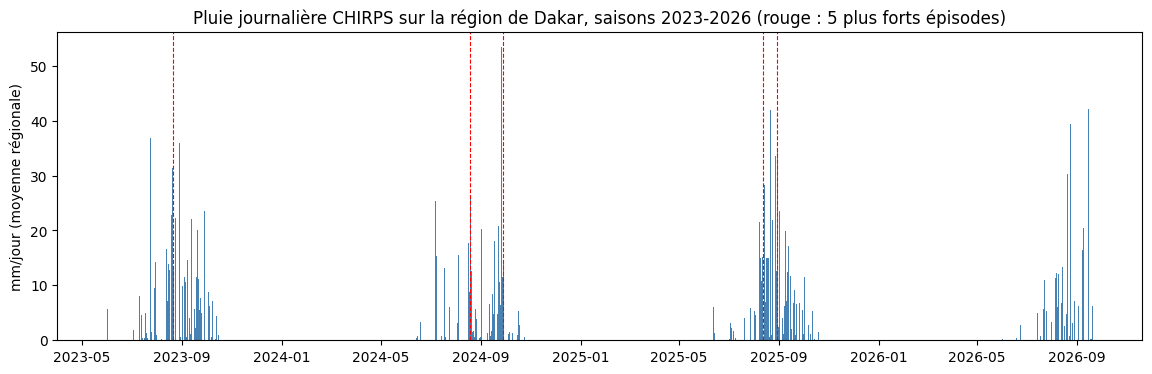

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
for annee, g in pluie.groupby(pluie.date.dt.year):
    ax.bar(g["date"], g["pluie_moy_mm"], width=1, color="steelblue")
for _, e in top10.head(5).iterrows():
    ax.axvline(e["fin_episode"], color="red", lw=0.8, ls="--")
ax.set_ylabel("mm/jour (moyenne régionale)")
ax.set_title("Pluie journalière CHIRPS sur la région de Dakar, saisons 2023-2026 (rouge : 5 plus forts épisodes)")
plt.show()

## 5. Diagnostic : pourquoi CHIRPS ne sert **pas** d'indicateur par commune

Pour chaque commune, on compte les pixels CHIRPS qui la touchent et ceux qui ont une valeur valide.

In [8]:
jour_ref, _, tableau_ref, transform_ref = next(r for r in resultats if r[1] == "definitif")
valide = tableau_ref != NODATA
couverture = []
for _, c in communes.iterrows():
    touche = ~geometry_mask([c.geometry], tableau_ref.shape, transform_ref, all_touched=True)
    couverture.append({"commune": c["commune"], "zone_prioritaire": c["zone_prioritaire"],
                       "pixels_touches": int(touche.sum()), "pixels_valides": int((touche & valide).sum())})
couverture = pd.DataFrame(couverture)
couverture.to_csv(PROCESSED / "chirps_couverture_communes.csv", index=False)
print(f"Communes sans aucun pixel CHIRPS valide : {(couverture.pixels_valides == 0).sum()} / {len(couverture)}")
couverture[couverture.zone_prioritaire.notna()].sort_values("pixels_valides")

Communes sans aucun pixel CHIRPS valide : 13 / 53


,commune,zone_prioritaire,pixels_touches,pixels_valides
20,Medina Gounass,Guédiawaye,1,0
23,Wakhinane Nimzatt,Guédiawaye,1,0
22,Sam Notaire,Guédiawaye,2,0
21,Ndiarème Limamoulaye,Guédiawaye,1,0
33,Guinaw Rail Nord,Pikine,2,0
34,Guinaw Rail Sud,Pikine,2,0
36,Pikine Est,Pikine,1,0
32,Djidah Thiaroye Kaw,Pikine,1,0
41,Tivaouane Diacksao,Pikine,2,0
40,Thiaroye-sur-Mer,Pikine,1,0


## Limites de ces données

- **Résolution de 5,5 km :** un pixel CHIRPS est plus grand que la plupart des communes (Pikine Est fait 0,75 km², Médina 2,3 km²).
- **Masque océan :** CHIRPS considère une grande partie de la presqu'île comme de la mer (-9999). **13 communes sur 53 n'ont aucun pixel valide, dont 11 communes prioritaires** (Pikine Nord et Est, Thiaroye, Guinaw Rail, Médina Gounass, Wakhinane…).
- **Conclusion :** CHIRPS ne permet pas de comparer les communes entre elles. On l'utilise seulement pour **dater** les fortes pluies à l'échelle de la région.
- CHIRPS combine satellite et stations au sol. Il **lisse les orages très localisés** et sous-estime souvent les pics de pluie urbains. Les épisodes identifiés sont fiables en date, beaucoup moins en intensité exacte.
- Les données 2026 de juillet à septembre sont **préliminaires**, avec moins de stations intégrées. Elles peuvent être révisées dans quelques semaines.